### 1. Giới thiệu

### 2. EDA


SV mô tả các thống kê tổng quan về tập dữ liệu (số mẫu, số đặc trưng của 1 mẫu, kiểu dữ liệu của mỗi đặc trưng, số mẫu dữ liệu trống của mỗi đặc trưng,...) và xuất ra các thống kê mô tả trực quan về các đặc trưng (ví dụ: dùng boxplot, histogram,…). Đặc biệt, cần xuất ra phân bố dữ liệu của các biến mục tiêu và các biến quan trọng (sẽ đưa vào mô hình) và so sánh xem có khác biệt (distribution shift) đáng kể nào giữa 2 tập huấn luyện và kiểm thử không.


In [7]:
%pip install pandas openpyxl


   ---------------------------------------- 0/2 [et-xmlfile]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [openpyxl]
   -------------------- ------------------- 1/2 [open


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd

train_path = f"E:/KHDL/Beginner/CK/data/Train.xlsx"
test_path = f"E:/KHDL/Beginner/CK/data/Test.xlsx"

train_df = pd.read_excel(train_path)
test_df = pd.read_excel(test_path)

# Kiểm tra nhanh dữ liệu
print(f"Kích thước tập Train: {train_df.shape}")
print(f"Kích thước tập Test: {test_df.shape}")

Kích thước tập Train: (17544, 15)
Kích thước tập Test: (8760, 15)


In [ ]:
pd.set_option("display.max_columns", None)

datasets = [("TRAIN", train_df), ("TEST", test_df)]

for name, df in datasets:
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

    print("=" * 60)
    print(f"📊 THỐNG KÊ TỔNG QUAN TẬP DỮ LIỆU: {name}")
    print("=" * 60)
    num_rows, num_cols = df.shape
    print(f"🔹 Số lượng mẫu (dòng): {num_rows:,}")
    print(f"🔹 Số lượng đặc trưng (cột): {num_cols}")
    print("-" * 60)
    missing_count = df.isnull().sum()
    missing_percentage = (missing_count / num_rows) * 100
    data_types = df.dtypes
    summary_table = pd.DataFrame(
        {
            "Kiểu dữ liệu": data_types,
            "Số mẫu trống (NaN)": missing_count,
            "Tỷ lệ trống (%)": missing_percentage.map("{:.2f}%".format),
        }
    )

    print(summary_table)
    print("\n" * 2)

📊 THỐNG KÊ TỔNG QUAN TẬP DỮ LIỆU: TRAIN
🔹 Số lượng mẫu (dòng): 17,544
🔹 Số lượng đặc trưng (cột): 15
------------------------------------------------------------
            Kiểu dữ liệu  Số mẫu trống (NaN) Tỷ lệ trống (%)
Year               int64                   0           0.00%
Month              int64                   0           0.00%
Day                int64                   0           0.00%
Hour               int64                   0           0.00%
Load               int64                   0           0.00%
Site-1 Temp      float64                   0           0.00%
Site-2 Temp      float64                   0           0.00%
Site-3 Temp      float64                   0           0.00%
Site-4 Temp      float64                   0           0.00%
Site-5 Temp      float64                   0           0.00%
Site-1 GHI         int64                   0           0.00%
Site-2 GHI         int64                   0           0.00%
Site-3 GHI         int64                   0 

In [ ]:
load_col = ['Load']
temp_cols = sorted([col for col in train_df.columns if 'Temp' in col])
ghi_cols = sorted([col for col in train_df.columns if 'GHI' in col])
all_cols = load_col + temp_cols + ghi_cols
stats_list = []
for year in sorted(train_df['Year'].unique()):
    year_df = train_df[train_df['Year'] == year][all_cols]
    stats = {
        'Mean': year_df.mean(),
        'Variance': year_df.var(),
        'Median': year_df.median(),
        'Min': year_df.min(),
        'Max': year_df.max(),
        'Skewness': year_df.skew(),
        'Kurtosis': year_df.kurt()
    }
    stats_df = pd.DataFrame(stats).T
    stats_df['Year'] = year
    stats_df = stats_df.set_index('Year', append=True).reorder_levels([1, 0])
    stats_list.append(stats_df)
summary_stats = pd.concat(stats_list)
summary_stats.columns = pd.MultiIndex.from_tuples([
    ('Load', ''),
    ('Temperature', 'Site 1'), ('Temperature', 'Site 2'), ('Temperature', 'Site 3'), 
    ('Temperature', 'Site 4'), ('Temperature', 'Site 5'),
    ('Global Horizontal Irradiance', 'Site 1'), ('Global Horizontal Irradiance', 'Site 2'), 
    ('Global Horizontal Irradiance', 'Site 3'), ('Global Horizontal Irradiance', 'Site 4'), 
    ('Global Horizontal Irradiance', 'Site 5')
])

print("Descriptive Statistics for Training Data (Years 1 & 2)")
display(summary_stats.style.format('{:.2f}'))

Descriptive Statistics for Training Data (Years 1 & 2)


C:\Users\HP\AppData\Local\Temp\ipykernel_16816\3896774045.py:28: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab20")(np.linspace(0, 1, len(df_year["Day"].unique())))


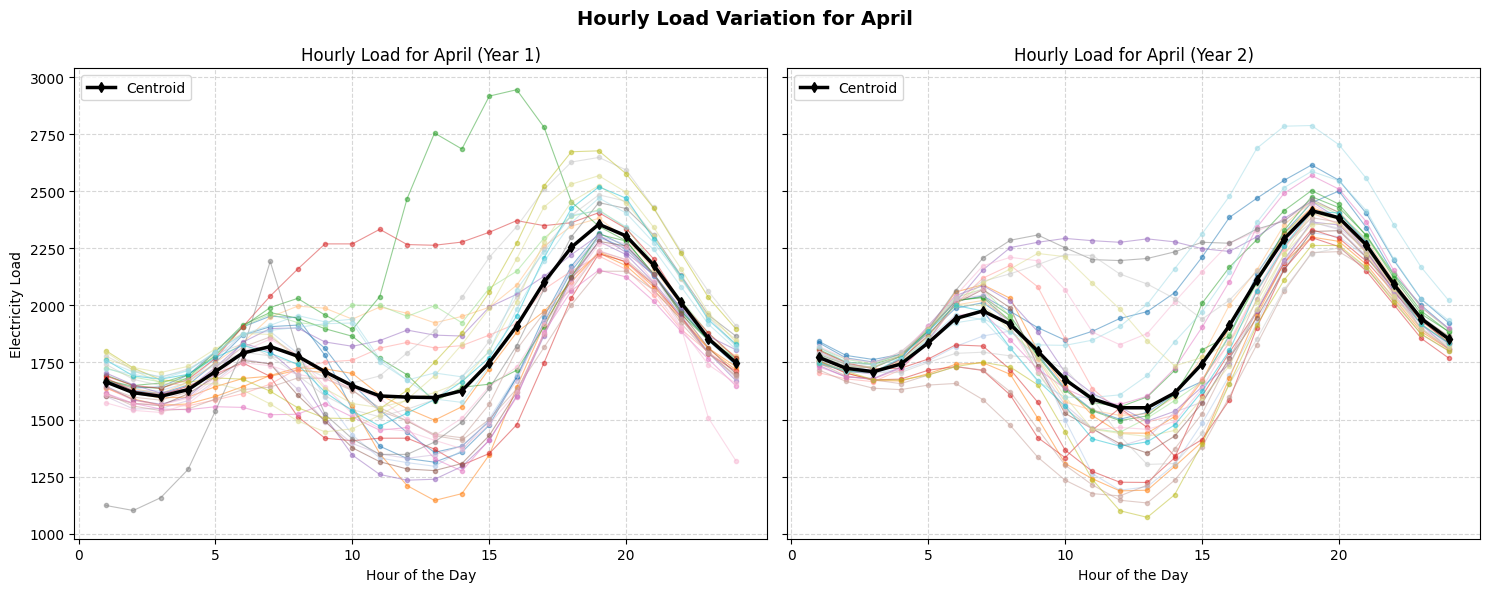

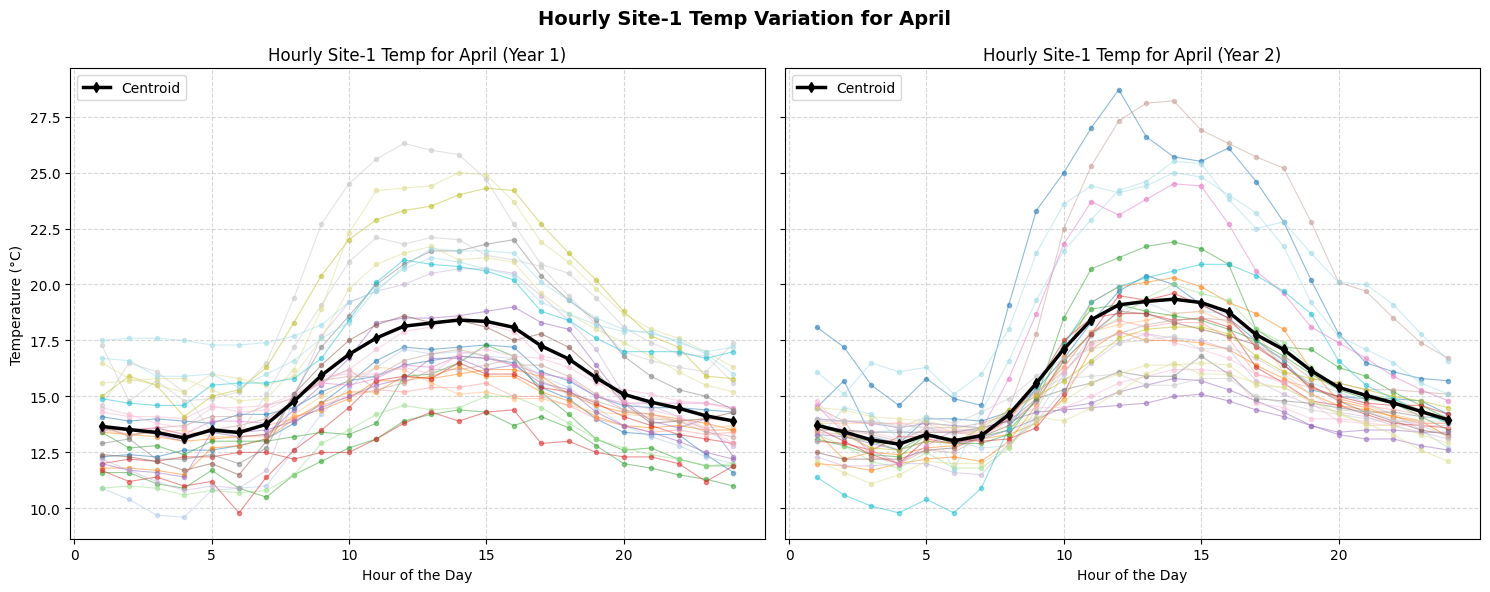

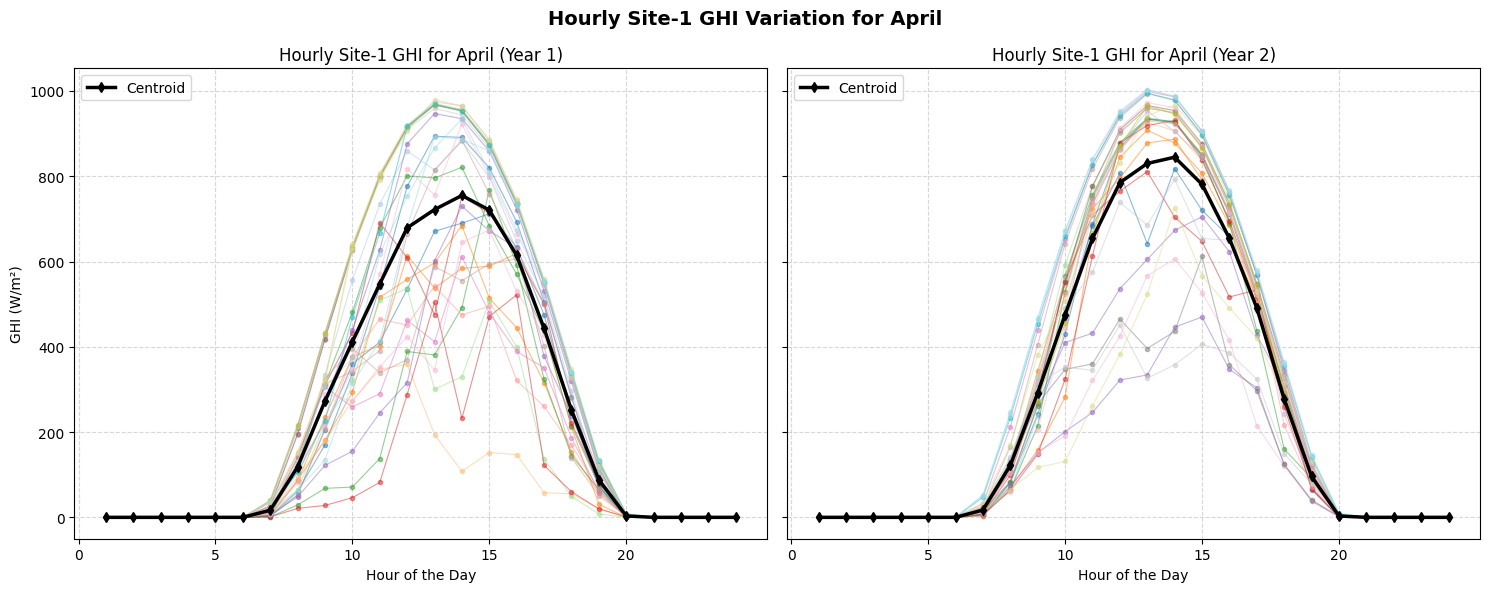

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_hourly_seasonality(df, column_to_plot, ylabel, month=4, month_name="April"):
    """Hàm vẽ biểu đồ biến thiên theo giờ cho từng ngày và đường Centroid trung bình"""
    df_month = df[df["Month"] == month].copy()
    df_month[column_to_plot] = pd.to_numeric(
        df_month[column_to_plot], errors="coerce"
    )
    fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
    unique_years = sorted(df_month["Year"].unique())
    for i, year in enumerate(unique_years[:2]): 
        ax = axes[i]
        df_year = df_month[df_month["Year"] == year]
        colors = plt.cm.get_cmap("tab20")(np.linspace(0, 1, len(df_year["Day"].unique())))
        for day_idx, day in enumerate(sorted(df_year["Day"].unique())):
            df_day = df_year[df_year["Day"] == day].sort_values("Hour")
            ax.plot(
                df_day["Hour"],
                df_day[column_to_plot],
                marker="o",
                markersize=3,
                linewidth=0.8,
                alpha=0.5,  # Làm mờ đường của từng ngày để không bị rối
                color=colors[day_idx],
            )
        centroid = df_year.groupby("Hour")[column_to_plot].mean().reset_index()
        ax.plot(
            centroid["Hour"],
            centroid[column_to_plot],
            color="black",
            linewidth=2.5,
            marker="d", 
            markersize=5,
            label="Centroid",
        )

        # Cấu hình hiển thị cho từng đồ thị con
        ax.set_title(f"Hourly {column_to_plot} for {month_name} (Year {year})")
        ax.set_xlabel("Hour of the Day")
        ax.set_xticks(
            range(0, 25, 5)
        )  
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="upper left")

    axes[0].set_ylabel(ylabel)
    fig.suptitle(
        f"Hourly {column_to_plot} Variation for {month_name}",
        fontsize=14,
        fontweight="bold",
    )
    plt.tight_layout()
    plt.show()

plot_hourly_seasonality(
    df_train, column_to_plot="Load", ylabel="Electricity Load", month=4
)

# 2. Vẽ cho Nhiệt độ trạm 1 (Site-1 Temp)
plot_hourly_seasonality(
    df_train, column_to_plot="Site-1 Temp", ylabel="Temperature (°C)", month=4
)

# 3. Vẽ cho Bức xạ mặt trời trạm 1 (Site-1 GHI)
plot_hourly_seasonality(
    df_train, column_to_plot="Site-1 GHI", ylabel="GHI (W/m²)", month=4
)

C:\Users\HP\AppData\Local\Temp\ipykernel_16816\606682243.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")(np.linspace(0, 1, len(unique_weeks)))
C:\Users\HP\AppData\Local\Temp\ipykernel_16816\606682243.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")(np.linspace(0, 1, len(unique_weeks)))


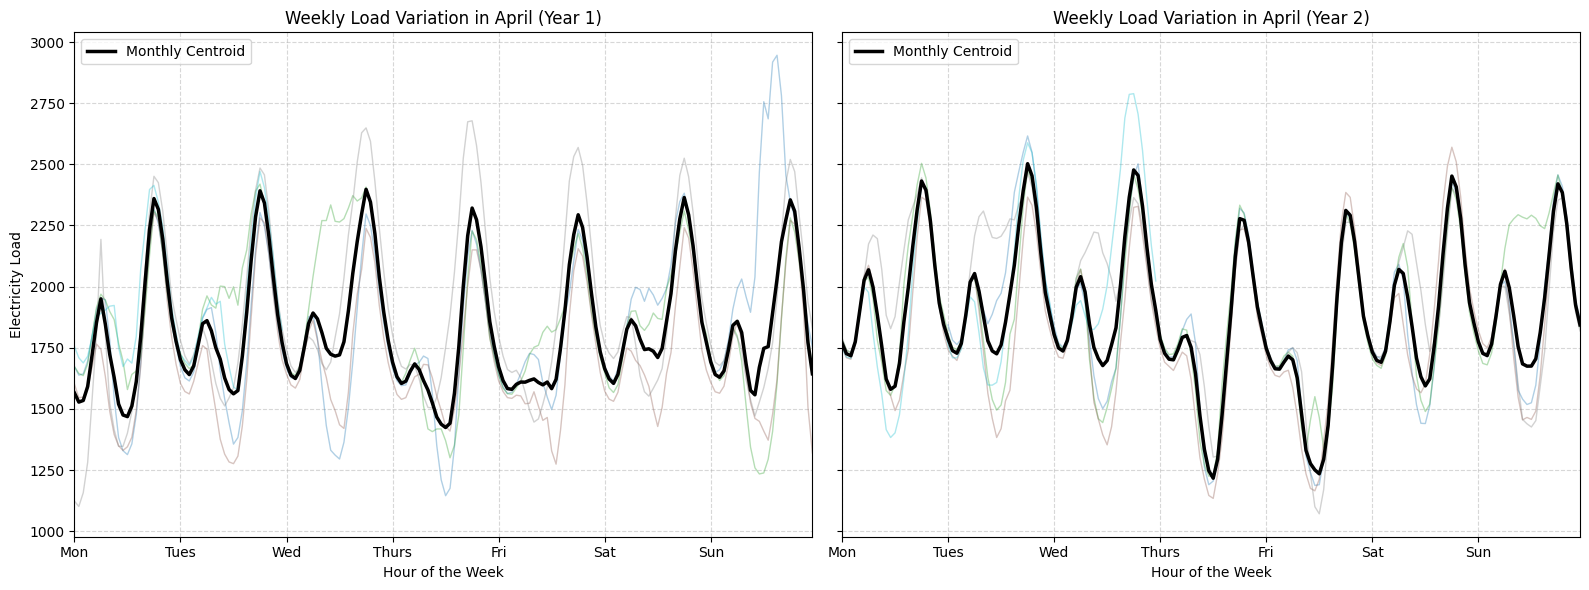

C:\Users\HP\AppData\Local\Temp\ipykernel_16816\606682243.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")(np.linspace(0, 1, len(unique_weeks)))
C:\Users\HP\AppData\Local\Temp\ipykernel_16816\606682243.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")(np.linspace(0, 1, len(unique_weeks)))


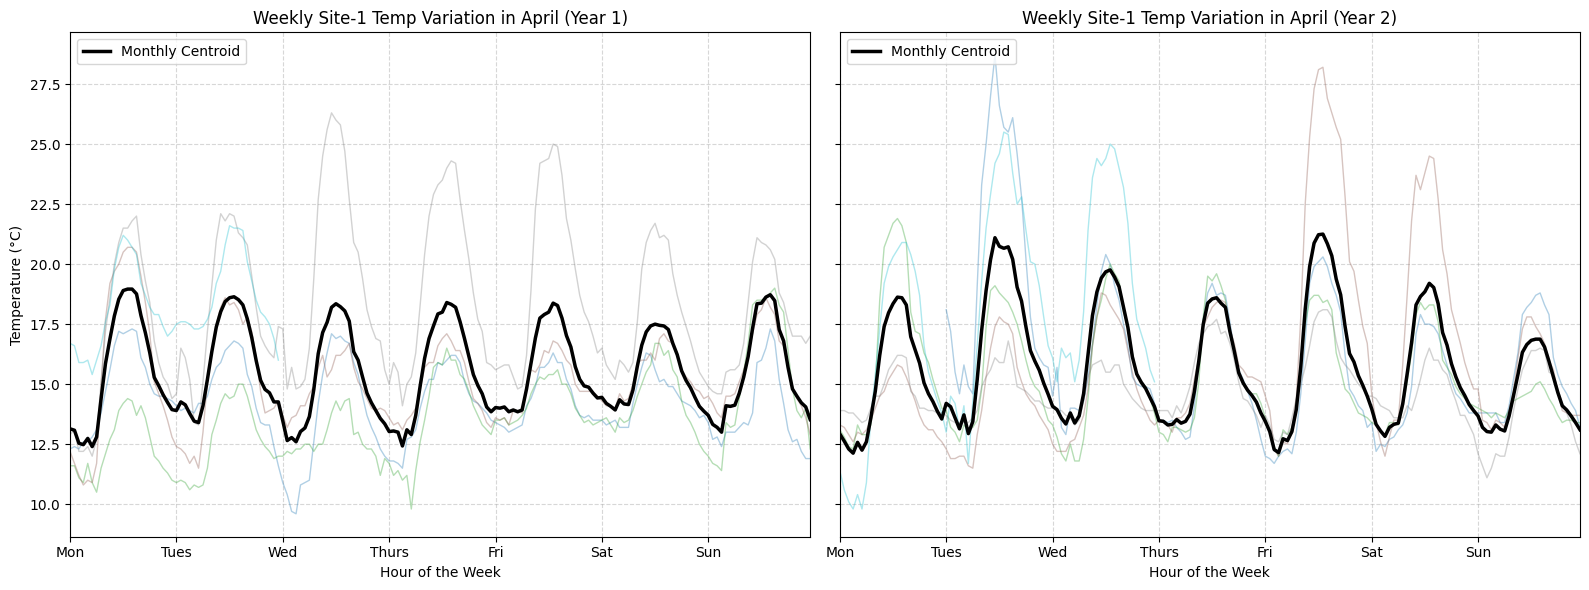

C:\Users\HP\AppData\Local\Temp\ipykernel_16816\606682243.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")(np.linspace(0, 1, len(unique_weeks)))
C:\Users\HP\AppData\Local\Temp\ipykernel_16816\606682243.py:66: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10")(np.linspace(0, 1, len(unique_weeks)))


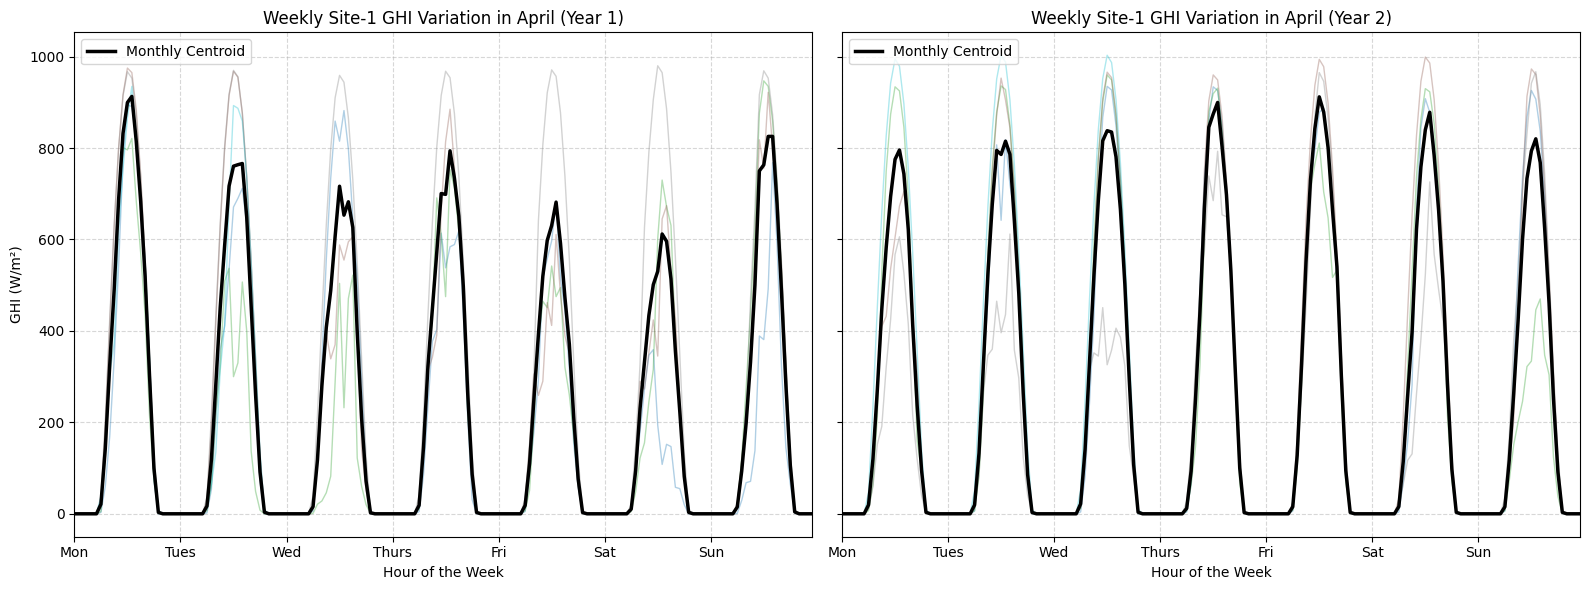

In [ ]:
def prepare_weekly_data(df):
    """Hàm tiền xử lý dữ liệu: Xác định thứ và tính toán giờ trong tuần (0 -> 167)"""
    df_copy = df.copy()
    for col in ["Year", "Month", "Day", "Hour"]:
        df_copy[col] = pd.to_numeric(df_copy[col], errors="coerce")
    df_copy["Actual_Year"] = df_copy["Year"].map({1: 2024, 2: 2025})
    temp_date_df = pd.DataFrame(
        {
            "year": df_copy["Actual_Year"],
            "month": df_copy["Month"],
            "day": df_copy["Day"],
        }
    )
    df_copy["Date"] = pd.to_datetime(temp_date_df, errors="coerce")
    df_copy["DayOfWeek"] = df_copy["Date"].dt.dayofweek
    df_copy["WeekOfYear"] = df_copy["Date"].dt.isocalendar().week
    hour_max = df_copy["Hour"].max()
    hour_norm = (
        df_copy["Hour"] - 1 if hour_max == 24 else df_copy["Hour"]
    )
    df_copy["Hour_of_Week"] = df_copy["DayOfWeek"] * 24 + hour_norm

    return df_copy


def plot_weekly_variational(
    df, column_to_plot, ylabel, month=4, month_name="April"
):
    """Hàm vẽ biểu đồ biến thiên theo tuần so sánh Year 1 và Year 2 kèm Monthly Centroid"""
    df_prepared = prepare_weekly_data(df)
    df_month = df_prepared[df_prepared["Month"] == month].copy()
    df_month[column_to_plot] = pd.to_numeric(
        df_month[column_to_plot], errors="coerce"
    )
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
    unique_years = sorted(df_month["Year"].unique())

    for i, year in enumerate(unique_years[:2]):
        ax = axes[i]
        df_year = df_month[df_month["Month"] == month]
        df_year = df_month[df_month["Year"] == year]
        unique_weeks = sorted(df_year["WeekOfYear"].unique())
        colors = plt.cm.get_cmap("tab10")(np.linspace(0, 1, len(unique_weeks)))
        for w_idx, week in enumerate(unique_weeks):
            df_week = df_year[df_year["WeekOfYear"] == week].sort_values(
                "Hour_of_Week"
            )
            if len(df_week) > 0:
                ax.plot(
                    df_week["Hour_of_Week"],
                    df_week[column_to_plot],
                    linewidth=1,
                    alpha=0.35,  # Làm mờ nét tuần để nổi bật đường trung bình
                    color=colors[w_idx],
                )

        centroid = (
            df_year.groupby("Hour_of_Week")[column_to_plot].mean().reset_index()
        )
        ax.plot(
            centroid["Hour_of_Week"],
            centroid[column_to_plot],
            color="black",
            linewidth=2.5,
            label="Monthly Centroid",
        )
        day_ticks = [0, 24, 48, 72, 96, 120, 144]
        day_labels = ["Mon", "Tues", "Wed", "Thurs", "Fri", "Sat", "Sun"]
        ax.set_xticks(day_ticks)
        ax.set_xticklabels(day_labels)
        ax.set_xlim(0, 167)

        ax.set_title(
            f"Weekly {column_to_plot} Variation in {month_name} (Year {year})"
        )
        ax.set_xlabel("Hour of the Week")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend(loc="upper left")

    axes[0].set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

plot_weekly_variational(
    df_train, column_to_plot="Load", ylabel="Electricity Load", month=4
)
plot_weekly_variational(
    df_train, column_to_plot="Site-1 Temp", ylabel="Temperature (°C)", month=4
)
plot_weekly_variational(
    df_train, column_to_plot="Site-1 GHI", ylabel="GHI (W/m²)", month=4
)

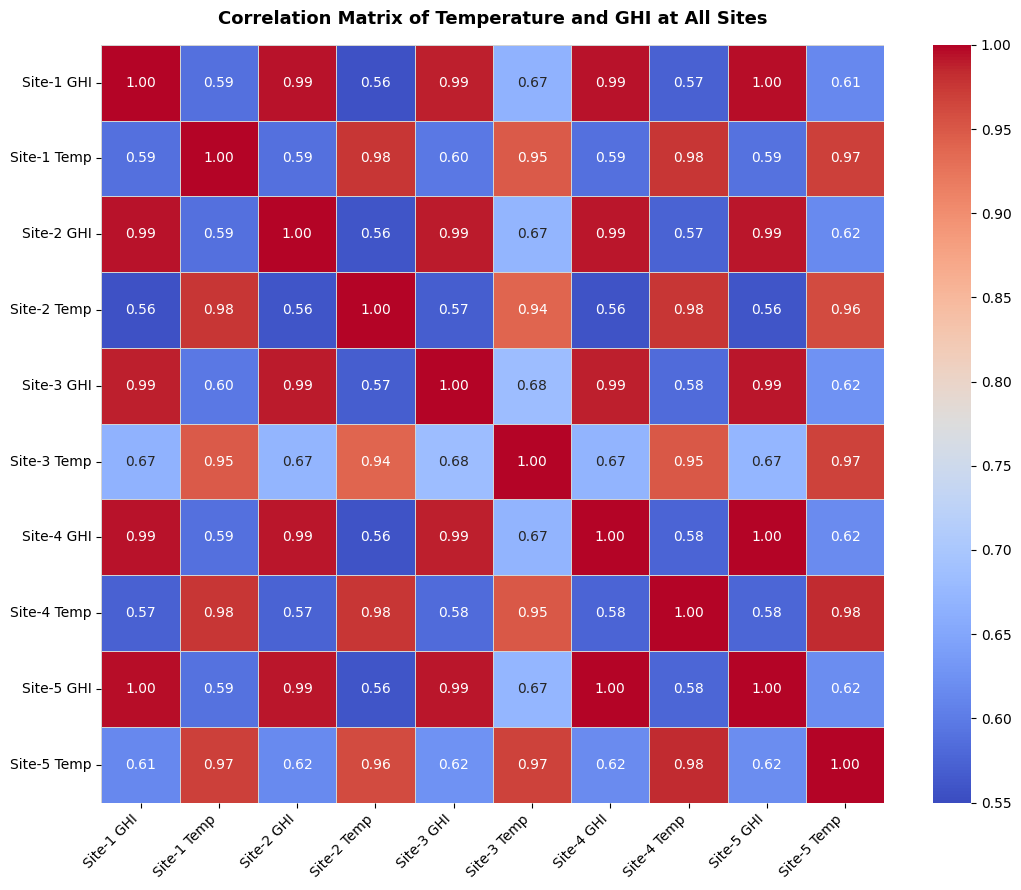

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
correlation_cols = [
    "Site-1 GHI",
    "Site-1 Temp",
    "Site-2 GHI",
    "Site-2 Temp",
    "Site-3 GHI",
    "Site-3 Temp",
    "Site-4 GHI",
    "Site-4 Temp",
    "Site-5 GHI",
    "Site-5 Temp",
]

for col in correlation_cols:
    df_train[col] = pd.to_numeric(df_train[col], errors="coerce")

corr_matrix = df_train[correlation_cols].corr()
plt.figure(figsize=(11, 9))

sns.heatmap(
    corr_matrix,
    annot=True,  
    fmt=".2f",  
    cmap="coolwarm",  
    vmin=0.55,  
    vmax=1.0,  
    linewidths=0.5,  
    linecolor="lightgray",  
)
plt.title(
    "Correlation Matrix of Temperature and GHI at All Sites",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
plt.xticks(
    rotation=45, ha="right", fontsize=10
)  
plt.yticks(rotation=0, fontsize=10) 

plt.tight_layout()
plt.show()

### 3.Feature Selection